In [341]:
# import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# connect to db
connection = sqlite3.connect("fracfocus.db")

# create cursor object
cursor = connection.cursor()

In [342]:
# select all disclosures, grouped by State to see which state has the most hydraulic fracturing 
statement = '''
    SELECT StateName, Latitude, Longitude, COUNT(*) as num_disclosures
    FROM disclosures
    WHERE Latitude IS NOT NULL
    AND Longitude IS NOT NULL
    GROUP BY StateName
    ORDER BY num_disclosures DESC;
'''
disclosures_by_state_df = pd.read_sql_query(statement, connection)


In [343]:
print('query 1 data')
disclosures_by_state_df

query 1 data


,StateName,Latitude,Longitude,num_disclosures
0,Texas,31.548838,-101.673378,10641
1,Oklahoma,34.625795,-97.567558,1854
2,Colorado,40.062648,-105.035359,1690
3,North Dakota,46.997940,-103.154870,1651
4,New Mexico,32.079511,-103.342281,1608
5,Pennsylvania,41.629150,-76.129660,973
6,Wyoming,42.526015,-109.657000,591
7,Utah,40.273700,-110.200786,477
8,Ohio,40.536295,-80.973149,398
9,Louisiana,32.379385,-93.510989,391


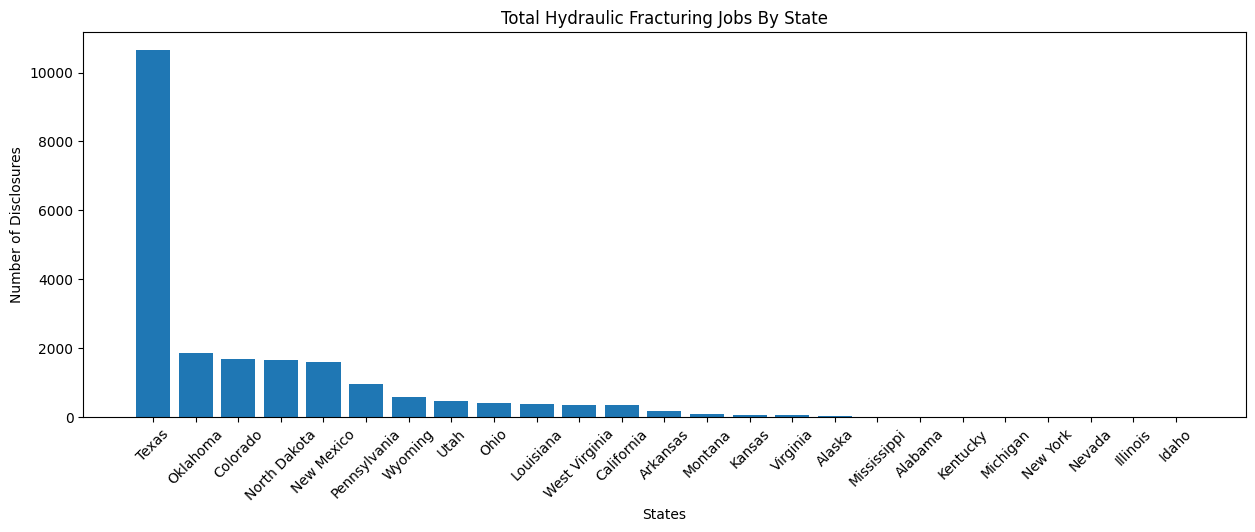

In [344]:
# graph in bar chart
plt.figure(figsize=(15,5))

plt.bar(disclosures_by_state_df['StateName'], disclosures_by_state_df['num_disclosures'])

plt.xticks(rotation=45)
plt.xlabel('States')
plt.ylabel('Number of Disclosures')
plt.title('Total Hydraulic Fracturing Jobs By State')

plt.show()

In [345]:
#most common chemicals used
# 56 381 of them are actually NULL
statement = '''
    SELECT IngredientName, COUNT(*) as num_disclosures
    FROM registry
    WHERE IngredientName is NOT NULL
    GROUP BY IngredientName
    ORDER BY num_disclosures DESC
    LIMIT 30;
'''
common_chemicals_df = pd.read_sql_query(statement, connection)
common_chemicals_df

,IngredientName,num_disclosures
0,Water,3255
1,Methanol,1242
2,Ethylene Glycol,663
3,"Crystalline silica, quartz",506
4,Hydrochloric Acid,484
5,Proprietary,468
6,Isopropanol,438
7,Sodium chloride,421
8,Ethanol,419
9,Sodium Chloride,353


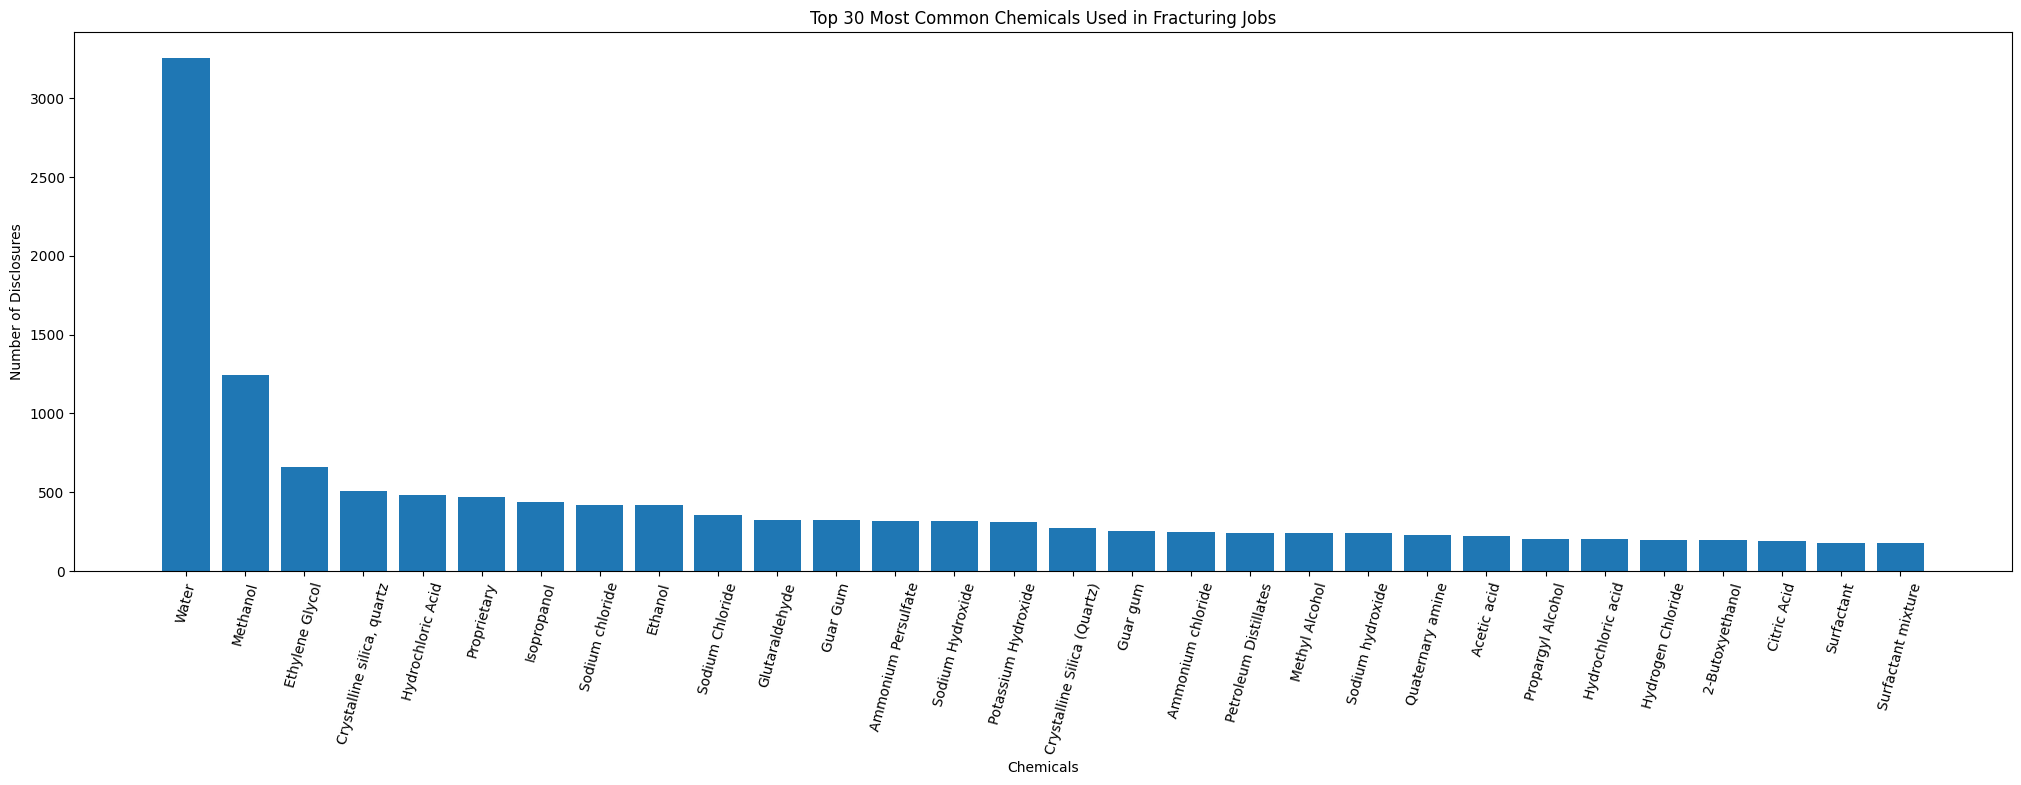

In [346]:
# graph in bar chart
plt.figure(figsize=(25,7))

plt.bar(common_chemicals_df['IngredientName'], common_chemicals_df['num_disclosures'])

plt.xticks(rotation=75)
plt.xlabel('Chemicals')
plt.ylabel('Number of Disclosures')
plt.title('Top 30 Most Common Chemicals Used in Fracturing Jobs')

plt.show()

In [347]:
# Water Use By Operator (with more than 10 Wells)
statement = '''
    SELECT OperatorName, strftime('%Y', JobStartDate) AS year, COUNT(*) as num_disclosures, SUM(TotalBaseWaterVolume) AS total_water_consump
    FROM disclosures
    WHERE TotalBaseWaterVolume is NOT NULL
    GROUP BY OperatorName
    HAVING num_disclosures > 10
    ORDER BY total_water_consump DESC;
'''
water_consump_by_operator_df = pd.read_sql_query(statement, connection)
water_consump_by_operator_df

,OperatorName,year,num_disclosures,total_water_consump
0,"EOG Resources, Inc.",2023,943,1.146825e+10
1,Pioneer Natural Resources,2019,609,9.359783e+09
2,XTO Energy/ExxonMobil,2016,737,9.107682e+09
3,Diamondback E&P LLC,2023,290,5.546322e+09
4,Devon Energy Production Company L. P.,2015,577,5.433428e+09
...,...,...,...,...
260,Evergreen Natural Resources LLC,2022,11,5.853960e+05
261,"Juno Operating Company II, LLC",2013,19,4.448480e+05
262,Unitex Oil Company,2014,13,4.242170e+05
263,1859 Operating LLC,2022,14,3.193260e+05


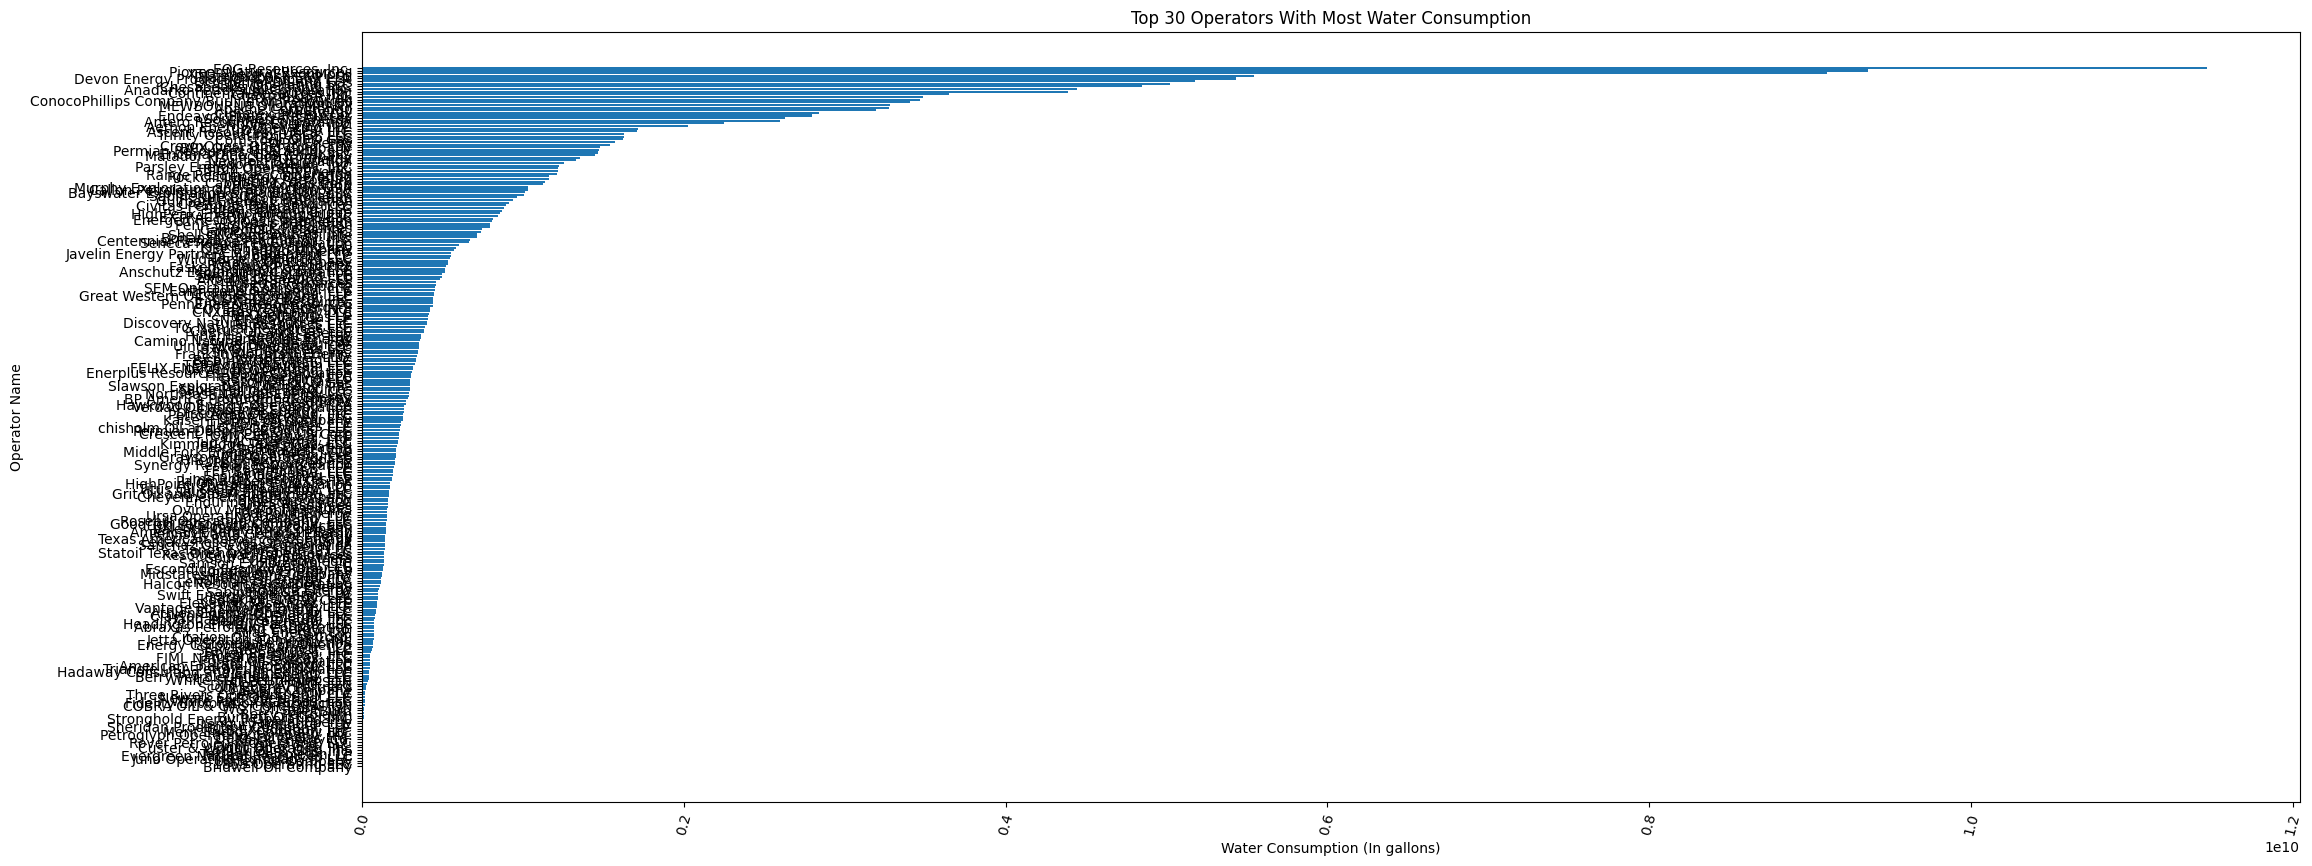

In [348]:
# graph in bar chart
plt.figure(figsize=(25,10))

plt.barh(water_consump_by_operator_df['OperatorName'], water_consump_by_operator_df['total_water_consump'])

plt.xticks(rotation=75)
plt.xlabel('Water Consumption (In gallons)')
plt.ylabel('Operator Name')
plt.title('Top 30 Operators With Most Water Consumption')

plt.gca().invert_yaxis()

plt.show()

In [349]:
# Top 30 Operators by # Disclosures
statement = '''
    SELECT OperatorName, COUNT(*) AS num_disclosures
    FROM disclosures
    GROUP BY OperatorName
    ORDER BY num_disclosures DESC
    LIMIT 30;
'''
top_operators_df = pd.read_sql_query(statement, connection)

# Operators by # Disclosures
statement = '''
    SELECT OperatorName, COUNT(*) AS num_disclosures
    FROM disclosures
    GROUP BY OperatorName
    ORDER BY num_disclosures DESC;
'''
operators_by_disclosures_df = pd.read_sql_query(statement, connection)

top_operators_df

,OperatorName,num_disclosures
0,"EOG Resources, Inc.",943
1,XTO Energy/ExxonMobil,737
2,Anadarko Petroleum Corporation,635
3,Pioneer Natural Resources,609
4,"Chesapeake Operating, Inc.",590
5,Devon Energy Production Company L. P.,577
6,Occidental Oil and Gas,533
7,ConocoPhillips Company/Burlington Resources,443
8,Apache Corporation,414
9,Marathon Oil,401


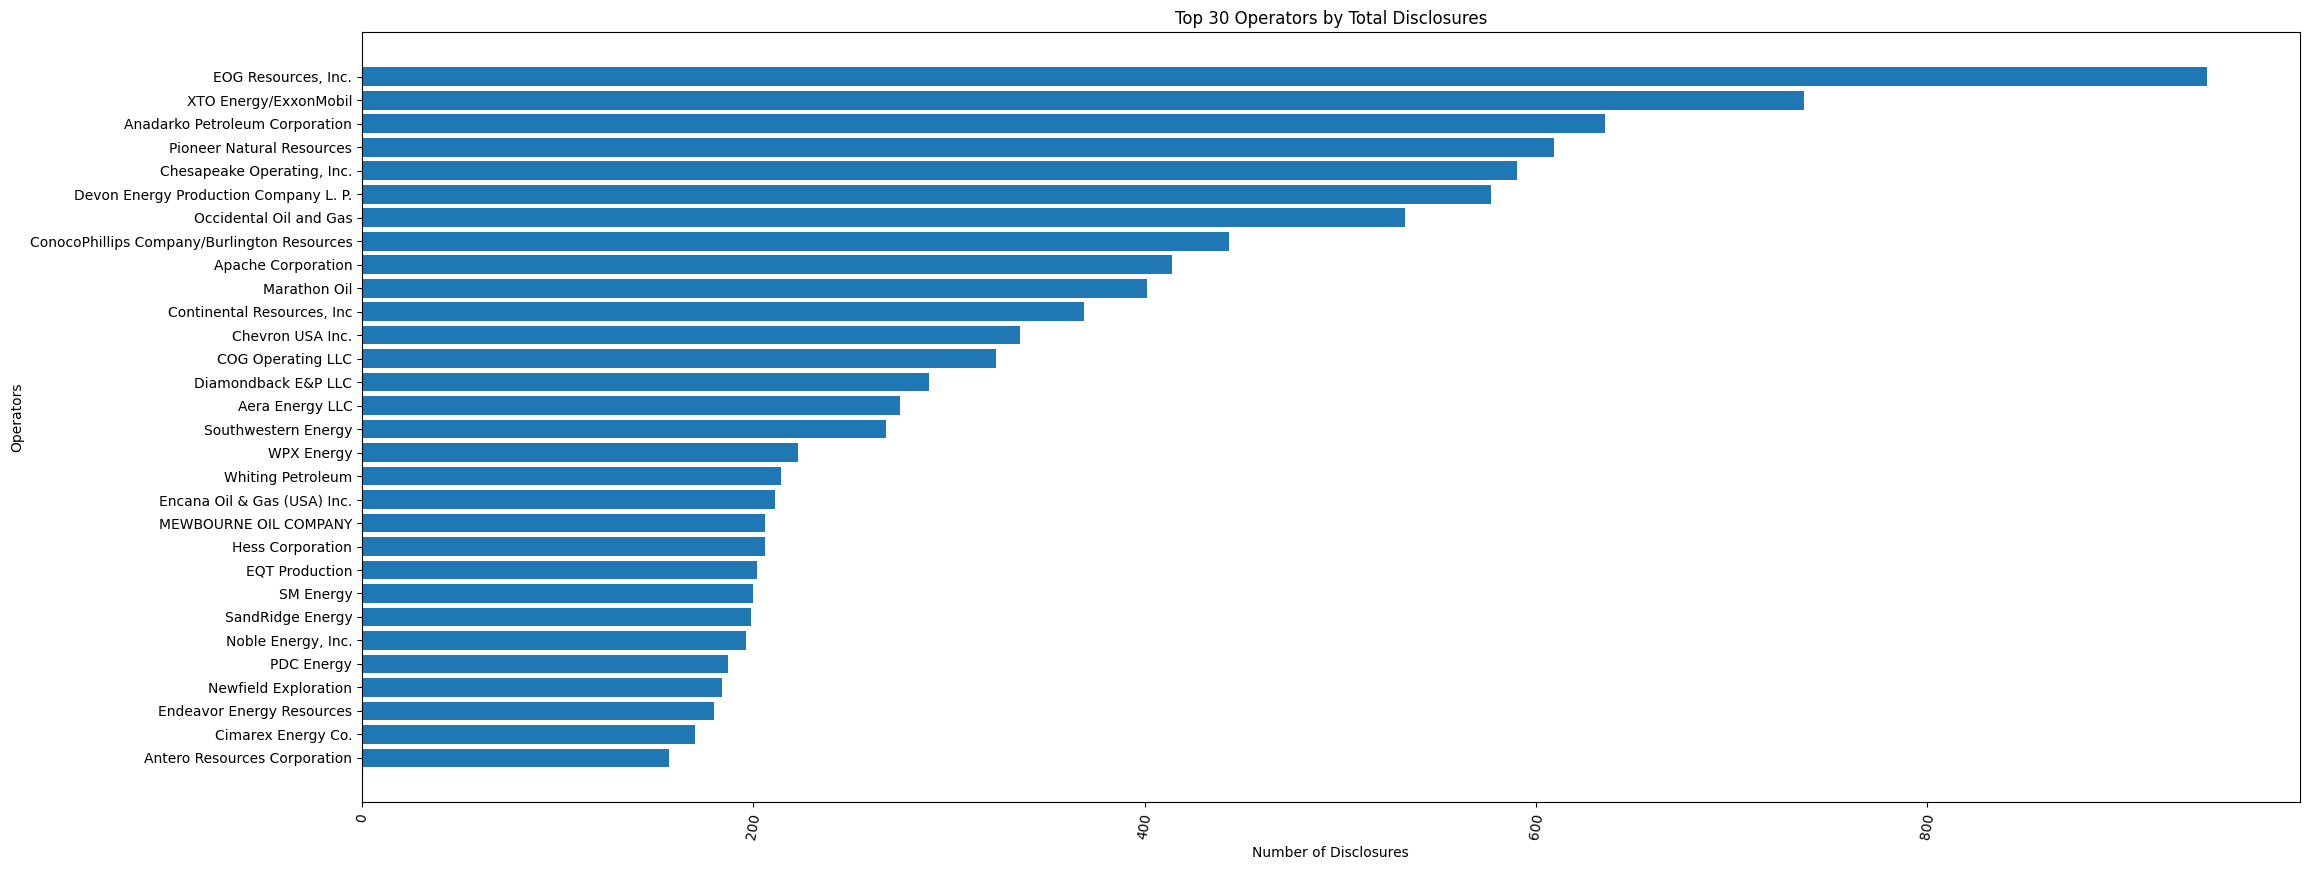

In [350]:
# graph in bar chart
plt.figure(figsize=(25,10))

plt.barh(top_operators_df['OperatorName'], top_operators_df['num_disclosures'])

plt.xticks(rotation=80)
plt.xlabel('Number of Disclosures')
plt.ylabel('Operators')
plt.title('Top 30 Operators by Total Disclosures')

plt.gca().invert_yaxis()

plt.show()

In [351]:
# avg water consumption over time per operator for top 10 operators (with most avg consumption)
#statement = '''
#    SELECT 
#        OperatorName,
#        strftime('%Y-%m', JobStartDate) AS month,
#        AVG(TotalBaseWaterVolume) as avg_water_consum
#    FROM disclosures
#    WHERE OperatorName IN (
#        SELECT OperatorName
#        FROM disclosures
#        WHERE TotalBaseWaterVolume is NOT NULL
#        GROUP BY OperatorName
#        ORDER BY AVG(TotalBaseWaterVolume) DESC
#        LIMIT 10
#    )
#    AND JobStartDate is NOT NULL
#    AND TotalBaseWaterVolume is NOT NULL
#    GROUP BY OperatorName, month
#    ORDER BY OperatorName, month;
#'''

statement = '''
    SELECT 
        OperatorName,
        COUNT(*) as num_disclosures,
        strftime('%Y', JobStartDate) AS year,
        AVG(TotalBaseWaterVolume) as avg_water_consum
    FROM disclosures
    WHERE TotalBaseWaterVolume is NOT NULL
    GROUP BY OperatorName
    ORDER BY OperatorName;
'''

water_consump_over_time_df = pd.read_sql_query(statement, connection)
water_consump_over_time_df

,OperatorName,num_disclosures,year,avg_water_consum
0,1776 Energy Operators,1,2025,9357012.00
1,1859 Operating LLC,14,2022,22809.00
2,"3R OPERATING, LLC",2,2026,13866429.50
3,89 Energy,1,2017,14454095.00
4,"ABARTA Oil & Gas Co., Inc.",1,2016,474810.00
...,...,...,...,...
1123,bracken operating llc,1,2024,134309.00
1124,"chisholm Oil and Gas Operating, LLC",20,2018,11740361.85
1125,donray petroleum llc.,4,2014,38787.00
1126,king energy llc,1,2014,0.00


In [352]:
# graph in line chart
#plt.figure(figsize=(25,10))

# converting month to datetime
#water_consump_over_time_df['month'] = pd.to_datetime(water_consump_over_time_df['month'])
# so line moves chronologically
#water_consump_over_time_df = water_consump_over_time_df.sort_values(['OperatorName', 'month'])

#for operator, group in water_consump_over_time_df.groupby('OperatorName'):
#    group = group.sort_values("month")
#    plt.plot(group['month'], group['avg_water_consum'], label=operator)

#plt.xticks(rotation=45)
#plt.xlabel('Month')
#plt.ylabel('Average Water Consumption')
#plt.title('Average Water Consumption Over Time By Top 10 Operators')

#plt.legend()

#plt.show()

In [353]:
# total jobs each year
statement = '''
    SELECT 
        strftime('%Y', JobStartDate) AS year,
        COUNT(8) as num_jobs
    FROM disclosures
    WHERE year IS NOT NULL
    GROUP BY year
    ORDER BY year
'''
jobs_per_year_df = pd.read_sql_query(statement, connection)
jobs_per_year_df

,year,num_jobs
0,2002,1
1,2010,6
2,2011,62
3,2012,888
4,2013,2844
5,2014,2872
6,2015,1635
7,2016,1053
8,2017,1443
9,2018,1765


## Export Visualization Df's

In [354]:
disclosures_by_state_df.to_csv('disclosures_by_state.csv', index=False)
common_chemicals_df.to_csv('common_chemicals_df.csv', index=False)
water_consump_by_operator_df.to_csv('water_consump_by_operator_df.csv', index=False)
top_operators_df.to_csv('top_operators_df.csv', index=False)
water_consump_over_time_df.to_csv('water_consump_over_time_df.csv', index=False)
operators_by_disclosures_df.to_csv('operators_by_disclosures_df.csv', index=False)
jobs_per_year_df.to_csv('jobs_per_year_df.csv', index=False)